# 🌲 Random Forest - Complete Learning Guide

## Overview
Random Forest is an ensemble learning algorithm that combines multiple decision trees to create a robust classifier. It's one of the most popular and versatile machine learning algorithms.

## Key Topics Covered:
1. **Ensemble Learning Basics** - Why ensemble methods work
2. **Bagging Concept** - Bootstrap aggregating
3. **Random Forest Architecture** - Building multiple trees
4. **Feature Importance** - Understanding feature contributions
5. **Hyperparameter Tuning** - Optimizing n_estimators, max_depth, etc.
6. **Comparison with Single Decision Trees** - Accuracy improvements
7. **Real-world Applications** - Practical examples
8. **Handling Class Imbalance** - Strategies for imbalanced data

---

## References:
- [scikit-learn Random Forest Documentation](https://scikit-learn.org/stable/modules/ensemble.html#random-forests)
- [Random Forest - Leo Breiman Paper](https://www.stat.berkeley.edu/~breiman/randomforest2001.pdf)
- [Random Forest Tutorial - StatQuest](https://www.youtube.com/watch?v=J4Wdy0Wc_xQ)

## 📚 Section 1: Import Libraries

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris, load_breast_cancer, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 🌳 Section 2: Ensemble Learning & Bagging

### Why Ensemble Methods Work?
- **Diversity**: Multiple models reduce individual model's errors
- **Stability**: Average predictions are more robust
- **Reduces overfitting**: Multiple weak learners combine into strong learner

### Bagging (Bootstrap Aggregating):
1. Create multiple random samples (with replacement) from training data
2. Train separate model on each sample
3. Aggregate predictions (voting for classification, averaging for regression)


🌳 EXAMPLE 1: Decision Tree vs Random Forest

✅ Model Performance:
  Single Decision Tree: 0.7333
  Random Forest (100 trees): 0.8333
  Improvement: 0.1000


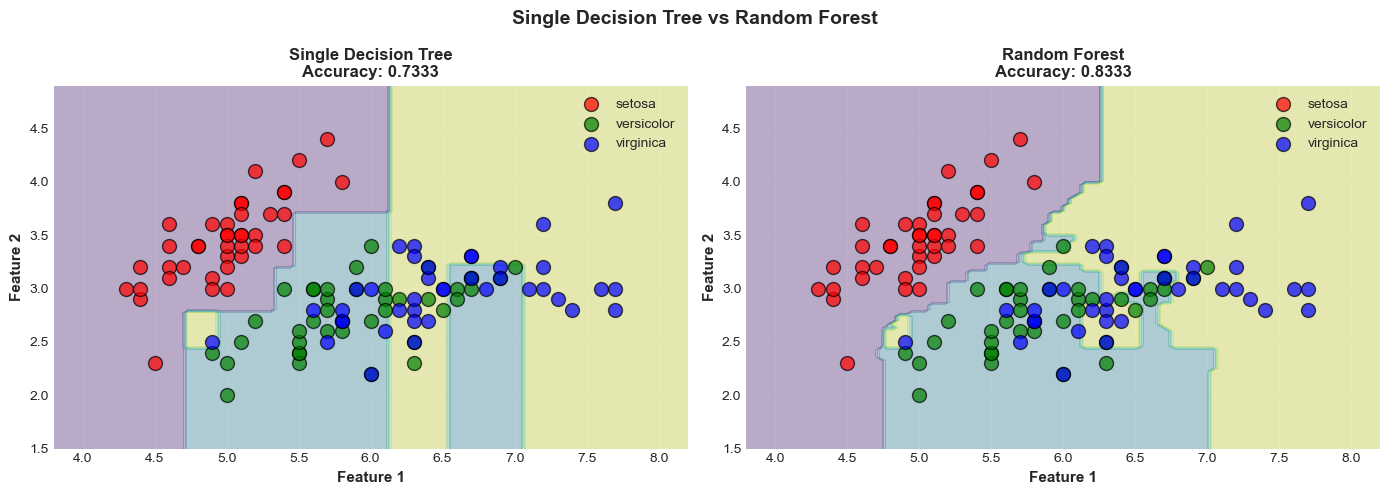

In [2]:
# Example 1: Single Tree vs Random Forest
print("\n" + "="*70)
print("🌳 EXAMPLE 1: Decision Tree vs Random Forest")
print("="*70)

# Load Iris dataset
iris = load_iris()
X_iris = iris.data[:, :2]  # Use first 2 features for visualization
y_iris = iris.target

# Split data
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

# Single Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_iris, y_train_iris)
y_pred_dt = dt.predict(X_test_iris)
acc_dt = accuracy_score(y_test_iris, y_pred_dt)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train_iris, y_train_iris)
y_pred_rf = rf.predict(X_test_iris)
acc_rf = accuracy_score(y_test_iris, y_pred_rf)

print(f"\n✅ Model Performance:")
print(f"  Single Decision Tree: {acc_dt:.4f}")
print(f"  Random Forest (100 trees): {acc_rf:.4f}")
print(f"  Improvement: {(acc_rf - acc_dt):.4f}")

# Visualize decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Single Decision Tree vs Random Forest', fontsize=14, fontweight='bold')

for idx, (model, title) in enumerate([(dt, 'Single Decision Tree'),
                                        (rf, 'Random Forest')]):
    ax = axes[idx]
    
    # Create mesh
    x_min, x_max = X_train_iris[:, 0].min() - 0.5, X_train_iris[:, 0].max() + 0.5
    y_min, y_max = X_train_iris[:, 1].min() - 0.5, X_train_iris[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                          np.linspace(y_min, y_max, 100))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision regions
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    
    # Plot data points
    colors = ['red', 'green', 'blue']
    for i, (color, label) in enumerate(zip(colors, iris.target_names)):
        mask = y_train_iris == i
        ax.scatter(X_train_iris[mask, 0], X_train_iris[mask, 1],
                  c=color, label=label, s=100, alpha=0.7, edgecolors='k')
    
    ax.set_xlabel('Feature 1', fontsize=11, fontweight='bold')
    ax.set_ylabel('Feature 2', fontsize=11, fontweight='bold')
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(y_test_iris, model.predict(X_test_iris)):.4f}',
                fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🌲 Section 3: Random Forest Architecture

### How Random Forest Works:
1. **Bootstrap Sampling**: Create B different subsets of training data
2. **Train B Decision Trees**: Each tree trained on one bootstrap sample
3. **Feature Randomness**: At each split, consider random subset of features
4. **Aggregate Predictions**:
   - Classification: Majority voting
   - Regression: Average prediction


🌲 EXAMPLE 2: Random Forest on Breast Cancer Dataset

📊 Dataset Information:
  Samples: 569
  Features: 30
  Classes: Malignant (0) = 212, Benign (1) = 357

✅ Random Forest Performance:
  Accuracy:  0.9649
  Precision: 0.9589
  Recall:    0.9859
  F1 Score:  0.9722
  ROC-AUC:   0.9953


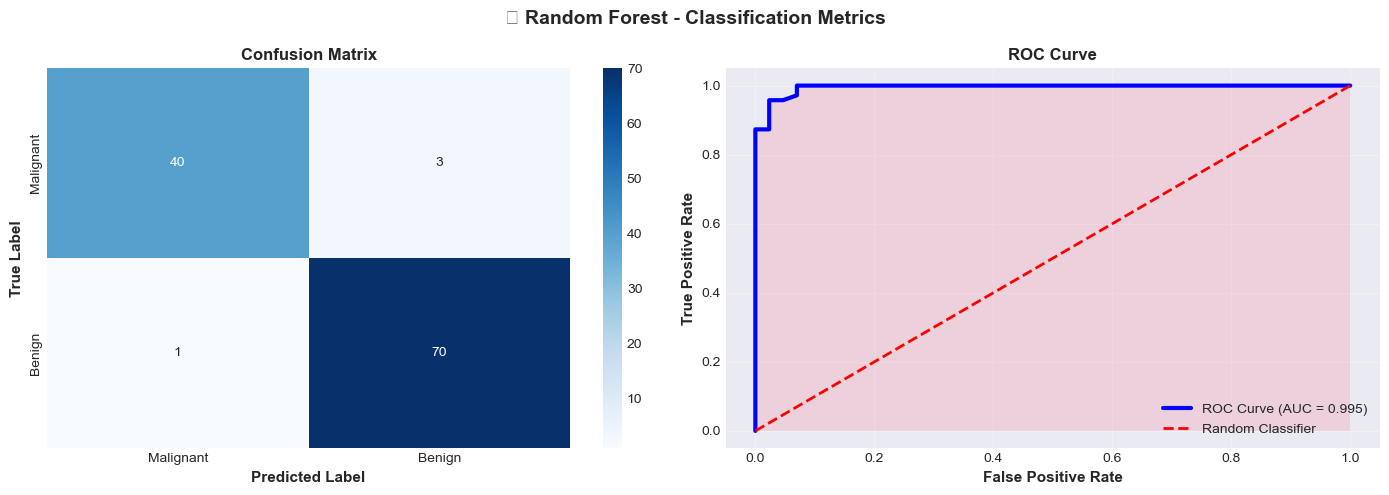

In [3]:
# Example 2: Random Forest on Real Dataset
print("\n" + "="*70)
print("🌲 EXAMPLE 2: Random Forest on Breast Cancer Dataset")
print("="*70)

# Load dataset
cancer_data = load_breast_cancer()
X_cancer = cancer_data.data
y_cancer = cancer_data.target

print(f"\n📊 Dataset Information:")
print(f"  Samples: {X_cancer.shape[0]}")
print(f"  Features: {X_cancer.shape[1]}")
print(f"  Classes: Malignant (0) = {(y_cancer == 0).sum()}, Benign (1) = {(y_cancer == 1).sum()}")

# Split data
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

# Train Random Forest
rf_cancer = RandomForestClassifier(n_estimators=100, max_depth=20,
                                    random_state=42, n_jobs=-1)
rf_cancer.fit(X_train_cancer, y_train_cancer)

# Predictions
y_pred_cancer = rf_cancer.predict(X_test_cancer)
y_pred_proba_cancer = rf_cancer.predict_proba(X_test_cancer)[:, 1]

# Metrics
accuracy = accuracy_score(y_test_cancer, y_pred_cancer)
precision = precision_score(y_test_cancer, y_pred_cancer)
recall = recall_score(y_test_cancer, y_pred_cancer)
f1 = f1_score(y_test_cancer, y_pred_cancer)
roc_auc = roc_auc_score(y_test_cancer, y_pred_proba_cancer)

print(f"\n✅ Random Forest Performance:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test_cancer, y_pred_cancer).ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🌲 Random Forest - Classification Metrics', fontsize=14, fontweight='bold')

# Confusion Matrix
ax = axes[0]
cm = confusion_matrix(y_test_cancer, y_pred_cancer)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
ax.set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test_cancer, y_pred_proba_cancer)
ax.plot(fpr, tpr, 'b-', linewidth=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2)
ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ⭐ Section 4: Feature Importance

### What is Feature Importance?
- Measures how much each feature contributes to the model's predictions
- Based on Gini importance (mean decrease in impurity)
- Helps with feature selection and understanding model behavior


⭐ EXAMPLE 3: Feature Importance

🎯 Top 10 Most Important Features:
   1. worst area                = 0.1539
   2. worst concave points      = 0.1447
   3. mean concave points       = 0.1062
   4. worst radius              = 0.0780
   5. mean concavity            = 0.0680
   6. worst perimeter           = 0.0671
   7. mean perimeter            = 0.0533
   8. mean radius               = 0.0487
   9. mean area                 = 0.0476
  10. worst concavity           = 0.0318


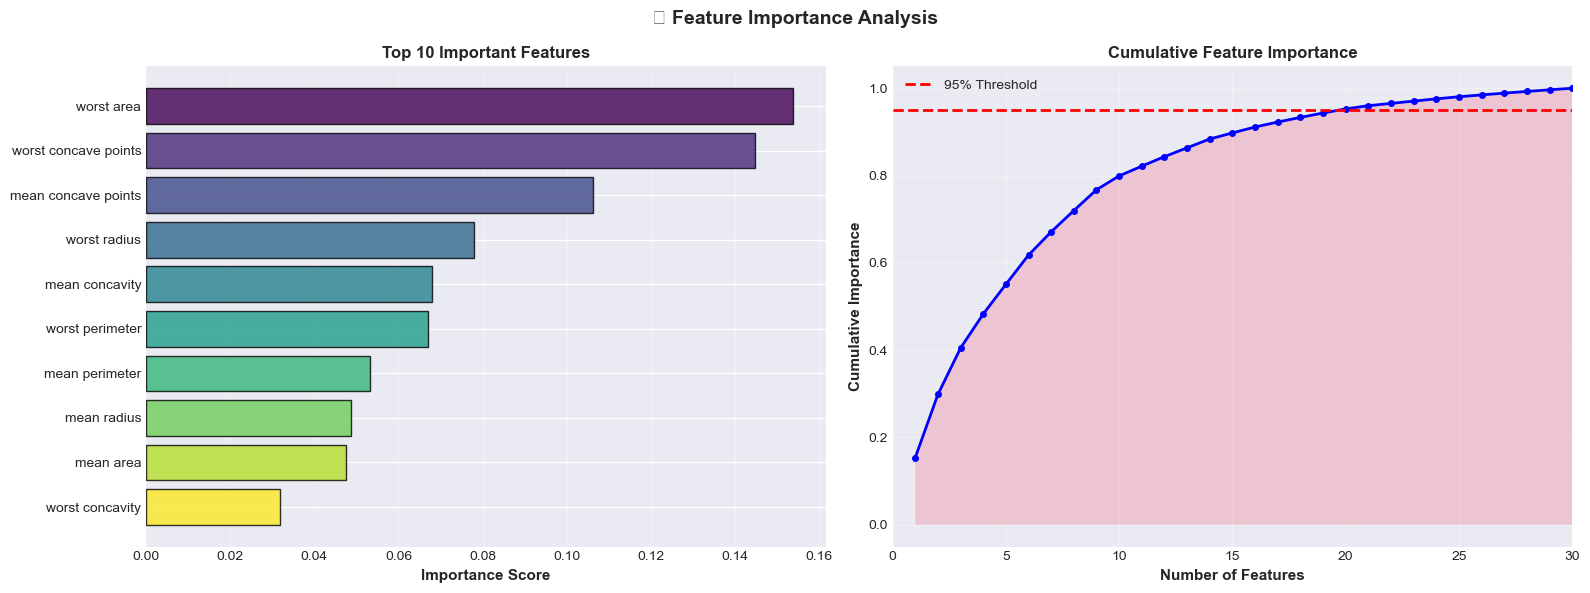


📊 Feature Reduction:
  Features for 95% importance: 20 out of 30
  Reduction: 33.3%


In [4]:
# Example 3: Feature Importance Analysis
print("\n" + "="*70)
print("⭐ EXAMPLE 3: Feature Importance")
print("="*70)

# Get feature importances
feature_importance = rf_cancer.feature_importances_
feature_names = cancer_data.feature_names

# Sort by importance
indices = np.argsort(feature_importance)[::-1]

print(f"\n🎯 Top 10 Most Important Features:")
for i, idx in enumerate(indices[:10], 1):
    print(f"  {i:2d}. {feature_names[idx]:25s} = {feature_importance[idx]:.4f}")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('⭐ Feature Importance Analysis', fontsize=14, fontweight='bold')

# Top 10 features - bar plot
ax = axes[0]
top_10_idx = indices[:10]
top_10_names = [feature_names[i] for i in top_10_idx]
top_10_importance = feature_importance[top_10_idx]

colors_bar = plt.cm.viridis(np.linspace(0, 1, 10))
ax.barh(range(10), top_10_importance, color=colors_bar, edgecolor='black', alpha=0.8)
ax.set_yticks(range(10))
ax.set_yticklabels(top_10_names, fontsize=10)
ax.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
ax.set_title('Top 10 Important Features', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Cumulative importance
ax = axes[1]
cumsum = np.cumsum(feature_importance[indices])
ax.plot(range(1, len(cumsum) + 1), cumsum, 'b-', linewidth=2, marker='o', markersize=4)
ax.axhline(y=0.95, color='r', linestyle='--', linewidth=2, label='95% Threshold')
ax.fill_between(range(1, len(cumsum) + 1), cumsum, alpha=0.3)
ax.set_xlabel('Number of Features', fontsize=11, fontweight='bold')
ax.set_ylabel('Cumulative Importance', fontsize=11, fontweight='bold')
ax.set_title('Cumulative Feature Importance', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_xlim([0, 30])

plt.tight_layout()
plt.show()

# Find number of features for 95% importance
n_features_95 = np.argmax(cumsum >= 0.95) + 1
print(f"\n📊 Feature Reduction:")
print(f"  Features for 95% importance: {n_features_95} out of {len(feature_importance)}")
print(f"  Reduction: {(1 - n_features_95/len(feature_importance))*100:.1f}%")

## ⚙️ Section 5: Hyperparameter Tuning

### Key Hyperparameters:
- **n_estimators**: Number of trees (more = better, but slower)
- **max_depth**: Maximum tree depth (controls overfitting)
- **min_samples_split**: Min samples to split node
- **min_samples_leaf**: Min samples in leaf node
- **max_features**: Features considered at each split

In [5]:
# Example 4: Hyperparameter Tuning
print("\n" + "="*70)
print("⚙️ EXAMPLE 4: Hyperparameter Tuning with GridSearchCV")
print("="*70)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print(f"\n🔍 Parameter Grid:")
print(f"  n_estimators: {param_grid['n_estimators']}")
print(f"  max_depth: {param_grid['max_depth']}")
print(f"  min_samples_split: {param_grid['min_samples_split']}")
print(f"  min_samples_leaf: {param_grid['min_samples_leaf']}")
total_combos = len(param_grid['n_estimators']) * len(param_grid['max_depth']) * \
               len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf'])
print(f"  Total combinations: {total_combos}")

print(f"\n⏳ Running GridSearchCV...")
grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid, cv=5, n_jobs=-1, verbose=0)
grid_search.fit(X_train_cancer, y_train_cancer)

print(f"\n✅ Best Parameters Found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"  Best CV Score: {grid_search.best_score_:.4f}")

# Test best model
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_cancer)
accuracy_tuned = accuracy_score(y_test_cancer, y_pred_tuned)

print(f"\n📊 Best Model Performance on Test Set:")
print(f"  Accuracy: {accuracy_tuned:.4f}")


⚙️ EXAMPLE 4: Hyperparameter Tuning with GridSearchCV

🔍 Parameter Grid:
  n_estimators: [50, 100, 200]
  max_depth: [10, 20, None]
  min_samples_split: [2, 5]
  min_samples_leaf: [1, 2]
  Total combinations: 36

⏳ Running GridSearchCV...

✅ Best Parameters Found:
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200
  Best CV Score: 0.9626

📊 Best Model Performance on Test Set:
  Accuracy: 0.9649

✅ Best Parameters Found:
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200
  Best CV Score: 0.9626

📊 Best Model Performance on Test Set:
  Accuracy: 0.9649


## 📈 Section 6: Impact of n_estimators

How accuracy changes with number of trees.


📈 EXAMPLE 5: Effect of Number of Trees

🌲 Testing different n_estimators:
  Trees:   1 -> Train: 0.9582, Test: 0.9386
  Trees:   5 -> Train: 0.9824, Test: 0.9474
  Trees:  10 -> Train: 0.9978, Test: 0.9561
  Trees:  25 -> Train: 1.0000, Test: 0.9649
  Trees:  50 -> Train: 1.0000, Test: 0.9649
  Trees: 100 -> Train: 1.0000, Test: 0.9649
  Trees:  50 -> Train: 1.0000, Test: 0.9649
  Trees: 100 -> Train: 1.0000, Test: 0.9649
  Trees: 200 -> Train: 1.0000, Test: 0.9649
  Trees: 300 -> Train: 1.0000, Test: 0.9649
  Trees: 200 -> Train: 1.0000, Test: 0.9649
  Trees: 300 -> Train: 1.0000, Test: 0.9649


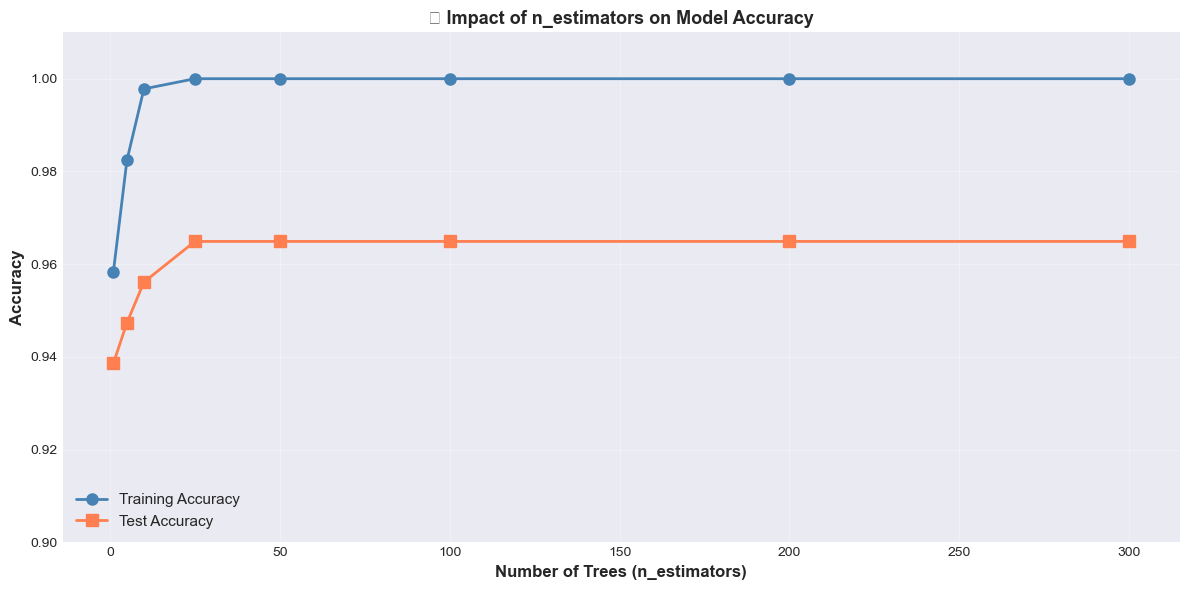

In [6]:
# Example 5: Effect of n_estimators
print("\n" + "="*70)
print("📈 EXAMPLE 5: Effect of Number of Trees")
print("="*70)

n_estimators_range = [1, 5, 10, 25, 50, 100, 200, 300]
train_scores = []
test_scores = []

print(f"\n🌲 Testing different n_estimators:")
for n in n_estimators_range:
    rf_temp = RandomForestClassifier(n_estimators=n, max_depth=20, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train_cancer, y_train_cancer)
    
    train_acc = accuracy_score(y_train_cancer, rf_temp.predict(X_train_cancer))
    test_acc = accuracy_score(y_test_cancer, rf_temp.predict(X_test_cancer))
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    print(f"  Trees: {n:3d} -> Train: {train_acc:.4f}, Test: {test_acc:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(n_estimators_range, train_scores, 'o-', linewidth=2, markersize=8,
        label='Training Accuracy', color='steelblue')
ax.plot(n_estimators_range, test_scores, 's-', linewidth=2, markersize=8,
        label='Test Accuracy', color='coral')

ax.set_xlabel('Number of Trees (n_estimators)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('📈 Impact of n_estimators on Model Accuracy', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.9, 1.01])

plt.tight_layout()
plt.show()

## 🔄 Section 7: Out-of-Bag (OOB) Error

### What is OOB Error?
- Samples not used in bootstrap sample (~37% for each tree)
- Used to estimate model performance without separate validation set
- Provides free cross-validation estimate

In [7]:
# Example 6: Out-of-Bag Error
print("\n" + "="*70)
print("🔄 EXAMPLE 6: Out-of-Bag (OOB) Error Estimation")
print("="*70)

# Train with OOB scoring
rf_oob = RandomForestClassifier(n_estimators=200, max_depth=20,
                                oob_score=True, random_state=42, n_jobs=-1)
rf_oob.fit(X_train_cancer, y_train_cancer)

# Predictions
y_pred_oob = rf_oob.predict(X_test_cancer)
test_accuracy = accuracy_score(y_test_cancer, y_pred_oob)
oob_accuracy = rf_oob.oob_score_

print(f"\n📊 Error Estimation Comparison:")
print(f"  OOB Score:     {oob_accuracy:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f}")
print(f"  Difference:    {abs(oob_accuracy - test_accuracy):.4f}")
print(f"\n✅ OOB provides reasonable estimate of test performance!")


🔄 EXAMPLE 6: Out-of-Bag (OOB) Error Estimation

📊 Error Estimation Comparison:
  OOB Score:     0.9604
  Test Accuracy: 0.9649
  Difference:    0.0045

✅ OOB provides reasonable estimate of test performance!

📊 Error Estimation Comparison:
  OOB Score:     0.9604
  Test Accuracy: 0.9649
  Difference:    0.0045

✅ OOB provides reasonable estimate of test performance!


## 🎓 Section 8: Random Forest vs Other Algorithms


🎓 EXAMPLE 7: Algorithm Comparison

🧪 Training and evaluating algorithms...

✅ Performance Comparison:
                     Accuracy  Precision    Recall        F1
Logistic Regression  0.956140   0.945946  0.985915  0.965517
Decision Tree        0.947368   0.957746  0.957746  0.957746
Random Forest        0.964912   0.958904  0.985915  0.972222
Gradient Boosting    0.964912   0.958904  0.985915  0.972222
KNN (k=5)            0.956140   0.934211  1.000000  0.965986

✅ Performance Comparison:
                     Accuracy  Precision    Recall        F1
Logistic Regression  0.956140   0.945946  0.985915  0.965517
Decision Tree        0.947368   0.957746  0.957746  0.957746
Random Forest        0.964912   0.958904  0.985915  0.972222
Gradient Boosting    0.964912   0.958904  0.985915  0.972222
KNN (k=5)            0.956140   0.934211  1.000000  0.965986


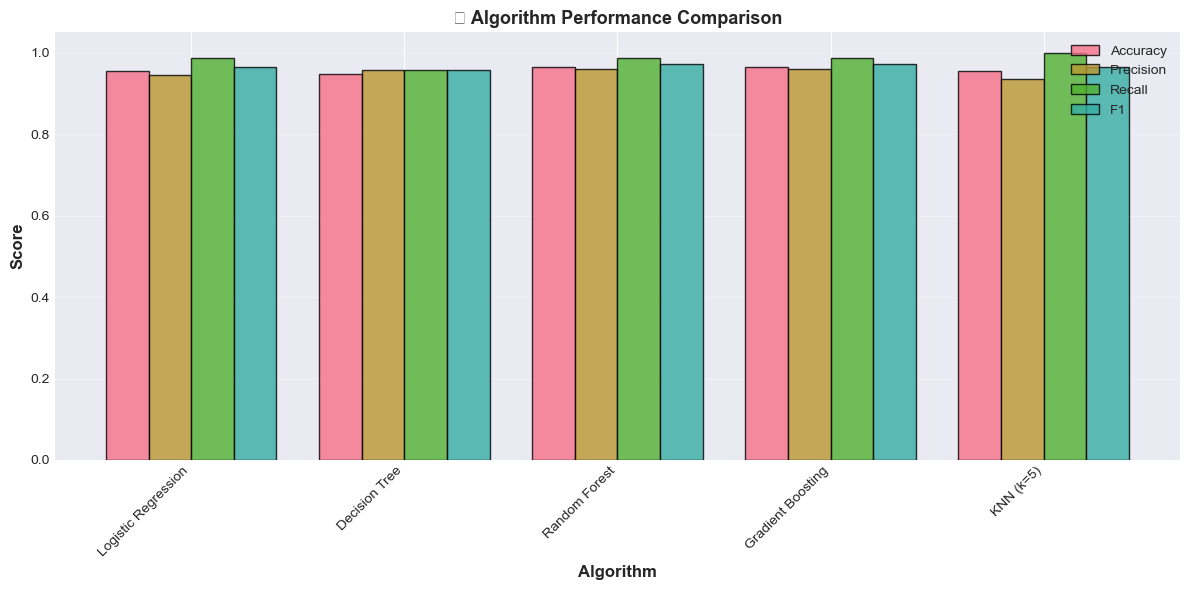

In [8]:
# Example 7: Algorithm Comparison
print("\n" + "="*70)
print("🎓 EXAMPLE 7: Algorithm Comparison")
print("="*70)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

algorithms = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=20, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

results = {}
print(f"\n🧪 Training and evaluating algorithms...")

for name, model in algorithms.items():
    model.fit(X_train_cancer, y_train_cancer)
    y_pred = model.predict(X_test_cancer)
    
    accuracy = accuracy_score(y_test_cancer, y_pred)
    precision = precision_score(y_test_cancer, y_pred)
    recall = recall_score(y_test_cancer, y_pred)
    f1 = f1_score(y_test_cancer, y_pred)
    
    results[name] = {'Accuracy': accuracy, 'Precision': precision,
                     'Recall': recall, 'F1': f1}

# Create results dataframe
results_df = pd.DataFrame(results).T
print(f"\n✅ Performance Comparison:")
print(results_df.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df.index))
width = 0.2
metrics = results_df.columns

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, results_df[metric], width, label=metric, alpha=0.8, edgecolor='black')

ax.set_xlabel('Algorithm', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('🎓 Algorithm Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

## 📋 Section 9: Random Forest Advantages & Disadvantages

### ✅ Advantages:
1. **High accuracy** - One of the best performing algorithms
2. **Handles non-linearity** - No need for feature engineering
3. **Feature importance** - Easy to understand feature contributions
4. **Handles missing values** - Can work with missing data
5. **Parallel training** - Easy to parallelize
6. **Less prone to overfitting** - Ensemble reduces variance
7. **Works on both classification and regression**

### ❌ Disadvantages:
1. **Slow predictions** - Must evaluate all trees
2. **High memory usage** - Stores many trees
3. **Difficult to interpret** - Harder than single tree
4. **Biased toward high cardinality features** - May favor certain features
5. **Class imbalance issues** - May not work well on imbalanced data
6. **Hyperparameter tuning** - Many parameters to tune

### When to Use:
- When you need high accuracy
- Medium to large datasets
- When feature importance matters
- Balanced classification problems
- When interpretability is secondary

In [9]:
# Example 8: Summary
print("\n" + "="*70)
print("🎓 KEY TAKEAWAYS")
print("="*70)

takeaways = [
    "Random Forest combines multiple decision trees to reduce overfitting",
    "Bagging (bootstrap aggregating) creates diversity in predictions",
    "Feature importance helps identify the most contributing features",
    "More trees usually = better performance (with diminishing returns)",
    "max_depth and min_samples_leaf control overfitting",
    "OOB error provides free cross-validation estimate",
    "Feature scaling is NOT needed for tree-based models",
    "Random Forest is one of the most robust algorithms",
    "Always check for feature importance in your model",
    "Consider Gradient Boosting for even better performance"
]

for i, takeaway in enumerate(takeaways, 1):
    print(f"\n{i:2d}. {takeaway}")

print(f"\n" + "="*70)


🎓 KEY TAKEAWAYS

 1. Random Forest combines multiple decision trees to reduce overfitting

 2. Bagging (bootstrap aggregating) creates diversity in predictions

 3. Feature importance helps identify the most contributing features

 4. More trees usually = better performance (with diminishing returns)

 5. max_depth and min_samples_leaf control overfitting

 6. OOB error provides free cross-validation estimate

 7. Feature scaling is NOT needed for tree-based models

 8. Random Forest is one of the most robust algorithms

 9. Always check for feature importance in your model

10. Consider Gradient Boosting for even better performance

